In [1]:
!wget https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/car_data.csv

--2025-09-09 17:22:21--  https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/car_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18812 (18K) [text/plain]
Saving to: ‘car_data.csv’

car_data.csv        100%[===================>]  18.37K  --.-KB/s    in 0.001s  

2025-09-09 17:22:21 (13.2 MB/s) - ‘car_data.csv’ saved [18812/18812]



In [2]:
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import numpy as np

# a) Exploración de datos

In [3]:
DataFrame = pd.read_csv('car_data.csv')
DataFrame.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Set
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,Train
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,Train
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,Train
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,Train
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,Test


In [5]:
print(DataFrame.shape)
print(type(DataFrame)) #OJO: DataFrame NO es una matriz
datos = DataFrame.drop(columns = ['Car_Name', 'Owner']) #descarto columnas
print(datos.shape)

(301, 10)
<class 'pandas.core.frame.DataFrame'>
(301, 8)


In [6]:
#Separo los Sets de train, test y validación
train = datos[datos['Set'] == 'Train']
train = train.drop(columns = ['Set'])

test = datos[datos['Set'] == 'Test']
test = test.drop(columns = ['Set'])

valid = datos[datos['Set'] == 'Validation']
valid = valid.drop(columns = ['Set'])


Mis variables categóricas son: Fuel_Type, Owner_Type y Transmission

Fuel_Type puede ser: Petrol, Diesel o GNC

Seller_Tpye puede ser: Dealer o Indivudual

Transmission puede ser: Manual o Automatic



In [7]:
#cálculo de las probabilidades de cada variable categórica
Petrol = datos[datos['Fuel_Type'] == 'Petrol']
Diesel = datos[datos['Fuel_Type'] == 'Diesel']
GNC = datos[datos['Fuel_Type'] == 'CNG']

print(f'La proporción de autos a Nafta es {len(Petrol)/len(datos):.3}')
print(f'La proporción de autos a Diesel es {len(Diesel)/len(datos):.3}')
print(f'La proporción de autos a GNC  es {len(GNC)/len(datos):.4f}')

La proporción de autos a Nafta es 0.794
La proporción de autos a Diesel es 0.199
La proporción de autos a GNC  es 0.0066


In [8]:
print(f'La proporción de autos con transmisión automática es {len(datos[datos['Transmission'] == 'Automatic'])/len(datos):.3}')
print(f'La proporción de autos con transmisión manual es {len(datos[datos['Transmission'] == 'Manual'])/len(datos):.3}')

La proporción de autos con transmisión automática es 0.133
La proporción de autos con transmisión manual es 0.867


In [9]:
print(f'La proporción de autos vendidos por concesionaria es {len(datos[datos['Seller_Type'] == 'Dealer'])/len(datos):.3}')

print(f'La proporción de autos vendidos por individuo es {len(datos[datos['Seller_Type'] == 'Individual'])/len(datos):.3}' )

La proporción de autos vendidos por concesionaria es 0.648
La proporción de autos vendidos por individuo es 0.352


# b) Pre-procesamiento

## OneHotEncoder

In [17]:
categoricas = ['Fuel_Type', 'Seller_Type','Transmission']
numericas = ['Year', 'Present_Price', 'Kms_Driven']

encoder = sk.preprocessing.OneHotEncoder(sparse_output = False, drop = 'if_binary')
#Nota: drop = 'if_binary' hace que las variables binarias sean 0 o 1 en lugar de crear 2 columnas
train_fit = encoder.fit_transform(train[categoricas])
print("Las 3 primeras filas de la matriz train_fit son: \n")
print(train_fit[0:3], "\n")

print("Las categorias generadas por el encoder son: \n")
print(encoder.categories_, "\n")

print("Las primeras filas de la data frame de entrenamiento es: \n")
print(train.iloc[0])

Las 3 primeras filas de la matriz train_fit son: 

[[0. 0. 1. 0. 1.]
 [0. 1. 0. 0. 1.]
 [0. 0. 1. 0. 1.]] 

Las categorias generadas por el encoder son: 

[array(['CNG', 'Diesel', 'Petrol'], dtype=object), array(['Dealer', 'Individual'], dtype=object), array(['Automatic', 'Manual'], dtype=object)] 

Las primeras filas de la data frame de entrenamiento es: 

Year               2014
Selling_Price      3.35
Present_Price      5.59
Kms_Driven        27000
Fuel_Type        Petrol
Seller_Type      Dealer
Transmission     Manual
Name: 0, dtype: object


## PolynomialFeatures

In [19]:
#Creo el mapa polinómico
polynomial = sk.preprocessing.PolynomialFeatures(degree = 3, include_bias = False) #Le saco el bias porque va a desapareces cuando reescale.
mapa = polynomial.fit_transform(train[numericas])

print(mapa.shape) #mapa con todos los productos cruzados posibles

(270, 19)


Observación: El mapa tiene 19 columnas poruqe esa es la cantidad de productos cruzados posibles con 3 variables (sacando el término independiente)

## ColumnTransformer

In [20]:
ColT = sk.compose.ColumnTransformer(
    #transformers = [(nombre, función a aplicar, nombres de las columnas a transformar)]
    transformers = [
        ('OHE', sk.preprocessing.OneHotEncoder(sparse_output = False, drop = 'if_binary'), categoricas),
        ('PolyMap', sk.preprocessing.PolynomialFeatures(degree = 3, include_bias = False), numericas)
    ]
)

train_CT = ColT.fit_transform(train) #columnas transformadas, sin escalar
print(train_CT.shape)

scaler = sk.preprocessing.StandardScaler() #creo la calse escalador
train_preprocesado = scaler.fit_transform(train_CT) #escalado. esta es la última etapa del preprocesamiento

print(train_preprocesado.shape)

#Lo hago dataframe para verlo más cómodo
train_pre_df = pd.DataFrame(train_preprocesado, columns = ColT.get_feature_names_out())
train_pre_df.head()

(270, 24)
(270, 24)


,OHE__Fuel_Type_CNG,OHE__Fuel_Type_Diesel,OHE__Fuel_Type_Petrol,OHE__Seller_Type_Individual,OHE__Transmission_Manual,PolyMap__Year,PolyMap__Present_Price,PolyMap__Kms_Driven,PolyMap__Year^2,PolyMap__Year Present_Price,...,PolyMap__Year^3,PolyMap__Year^2 Present_Price,PolyMap__Year^2 Kms_Driven,PolyMap__Year Present_Price^2,PolyMap__Year Present_Price Kms_Driven,PolyMap__Year Kms_Driven^2,PolyMap__Present_Price^3,PolyMap__Present_Price^2 Kms_Driven,PolyMap__Present_Price Kms_Driven^2,PolyMap__Kms_Driven^3
0,-0.086387,-0.494206,0.505781,-0.760886,0.404714,0.126871,-0.238090,-0.250867,0.126273,-0.238049,...,0.125674,-0.238009,-0.250473,-0.194271,-0.299843,-0.145707,-0.103346,-0.164884,-0.286916,-0.082712
1,-0.086387,2.023447,-1.977142,-0.760886,0.404714,-0.215681,0.203504,0.144817,-0.216570,0.203375,...,-0.217458,0.203243,0.146503,-0.087121,0.075911,-0.074175,-0.089077,-0.093590,-0.100954,-0.074866
2,-0.086387,-0.494206,0.505781,-0.760886,0.404714,1.154529,0.238161,-0.747944,1.155823,0.240232,...,1.157116,0.242305,-0.749996,-0.075996,-0.420020,-0.189257,-0.087279,-0.168930,-0.336355,-0.085250
3,-0.086387,-0.494206,0.505781,-0.760886,0.404714,-0.900786,-0.399076,-0.789986,-0.901744,-0.399858,...,-0.902699,-0.400640,-0.793185,-0.219482,-0.487486,-0.190579,-0.105469,-0.182398,-0.341246,-0.085275
4,-0.086387,2.023447,-1.977142,-0.760886,0.404714,1.497081,0.235925,-0.867366,1.499346,0.238537,...,1.501613,0.241154,-0.870436,-0.076617,-0.489153,-0.192030,-0.087398,-0.179830,-0.342206,-0.085292


# c) Regresión lineal

In [21]:
LinReg = sk.linear_model.LinearRegression() #defino la clase para la regresión lineal

pipeline = sk.pipeline.Pipeline(
    [
        #sintaxis: ('Nombre de la etapa', Clase de sklearn asoicada a la etapa)
        ('Column Transformer', ColT),
        ('Scaler', scaler),
        ('Regresion Lineal', LinReg)

    ]
)
#Nota: El pipeline engloba una serie de pasos para procesar los datos. Recibe una dupla con (el nombre del paso, procesador/estimador)
#el procesador es un objeto de sklearn YA CREADO (como son el columnTransformer o el scaler en mi caso)
#Lo mismo para el estimador.
#en general las primeras clases del pipeline son transformadores y la última es un estimador. No es estrictamente necesario
#que sea así, pero es la idea.
#los trasformadores tienen métodos de fit y transform. El estimador tiene metodos fit y predict


display(pipeline)


Pipeline(steps=[('Column Transformer',
                 ColumnTransformer(transformers=[('OHE',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['Fuel_Type', 'Seller_Type',
                                                   'Transmission']),
                                                 ('PolyMap',
                                                  PolynomialFeatures(degree=3,
                                                                     include_bias=False),
                                                  ['Year', 'Present_Price',
                                                   'Kms_Driven'])])),
                ('Scaler', StandardScaler()),
                ('Regresion Lineal', LinearRegression())])

Nota: El pipeline engloba una serie de pasos para procesar los datos. Recibe una dupla con (el nombre del paso, procesador/estimador)
el procesador es un objeto de sklearn YA CREADO (como son el columnTransformer o el scaler en mi caso)
Lo mismo para el estimador.

En general las primeras clases del pipeline son transformadores y la última es un estimador. No es estrictamente necesario
que sea así, pero es la idea.

Los trasformadores tienen métodos de fit y transform. El estimador tiene metodos fit y predict

In [24]:
#separo la variable a predecir y las que se usan en la regresión
X_train = train[categoricas + numericas]
Y_train = train['Selling_Price']

pipeline.fit(X_train, Y_train) #entreno el sistema
#Nota: acá le puedo pasar los datos recién salidos del CSV porque el pipeline engloba todo el prepocesamiento

parametros = pipeline.named_steps['Regresion Lineal'].coef_
#con .named_steps['nombre del paso'] me meto en la clase asociada al paso
print(f'En la regresión lineal se entrenan {len(parametros)} coeficientes')

En la regresión lineal se entrenan 24 coeficientes


Se están buscando los coeficientes de un polinomio de grado 3. El polinomio es de 3 variables (las tres variables numéricas con las que se trabaja), por lo que tendrá términos con todos los productos posibles de hasta tercer orden ($x\cdot x$, $x\cdot y$, $x\cdot z$, etc) y un término lineal.

Si $\nu$ es la cantidad de variables numéricas y $g$ es el grado del polinomio, el problema de la regresión consiste en buscar la siguiente cantidad de parámetros:

$$
\binom{\nu+g}{g} = \frac{\nu!}{g!\,(\nu-g)!}
$$

que en nuestro caso es:

$$
\binom{3 + 3}{3} = 20
$$

Además excluimos el término independiente porque se estandariza el mapa polinómico, lo que solo agregaría una columna de ceros, por lo que se cuentan 19 coeficientes.

Por último hay que considerar los parámetros que añaden las variables categóricas a la regresión. 2 de ellas son binarias se suman 2 parámetros más, y la tercera puede tomar tres valores (el combustible puede ser GNC, Nafta o Diesel), lo que suma 3 parámetros más.

Por lo tanto, el modelo tiene 19 + 5 = 24 parámetros

In [25]:
#Predigo con los datos de entrenamiento
Y_hat_train = pipeline.predict(X_train) #Y_hat es de tipo numpy.ndarray, pero Y_valid es un pandas.Series. Igual no pasa nada
mse_train = np.mean((Y_hat_train - Y_train)**2) #error en la predicción

X_valid = valid[categoricas + numericas]
Y_valid = valid['Selling_Price']

Y_hat_valid = pipeline.predict(X_valid)#predigo con las variables de validación
mse_valid = np.mean((Y_hat_valid - Y_valid)**2)#error de la predicción con las variables de validación

print(f'El MSE de entrenamiento es de {mse_train}')
print(f'El MSE de validación es de {mse_valid}')


El MSE de entrenamiento es de 0.4726923559497071
El MSE de validación es de 0.541999155140006


# d) Regularización

In [26]:
regularizacion = sk.linear_model.Ridge()
#si bien al crear esta clase habría que definier el parámetro alpha (o lambda según el tp), no es necesario hacerlo ahora
#el parámetro se puede especificar después con regularizacion.set_params(alpha = algo)

parametros = regularizacion.get_params()
#¿Qué parámetros hay? Estos:
display(parametros)

#defino el nuevo pipeline
pl_regu = sk.pipeline.Pipeline(
    (('Column Transformer', ColT),
        ('Scaler', scaler),
        ('Regularizacion', regularizacion))
)

display(pl_regu)

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': None,
 'solver': 'auto',
 'tol': 0.0001}

Pipeline(steps=(('Column Transformer',
                 ColumnTransformer(transformers=[('OHE',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['Fuel_Type', 'Seller_Type',
                                                   'Transmission']),
                                                 ('PolyMap',
                                                  PolynomialFeatures(degree=3,
                                                                     include_bias=False),
                                                  ['Year', 'Present_Price',
                                                   'Kms_Driven'])])),
                ('Scaler', StandardScaler()), ('Regularizacion', Ridge())))

In [27]:
lambdas = np.logspace(start = -6, stop = -2, num = 100)

## Entrenamiento para distintos $λ$

In [28]:
mse_train_list = []
mse_valid_list = []

for lam in lambdas:
    #seteo el lambda
    regularizacion.set_params(alpha = lam)
    #entreno
    pl_regu.fit(X_train, Y_train)

    #error de entrenamiento
    Y_hat_train = pl_regu.predict(X_train)
    mse_train = np.mean((Y_hat_train - Y_train)**2)
    mse_train_list.append(mse_train)

    #error de validación
    Y_hat_valid = pl_regu.predict(X_valid)
    mse_valid = np.mean((Y_hat_valid - Y_valid)**2)
    mse_valid_list.append(mse_valid)

## Búsqueda del mejor $λ$ y el ECM asociado

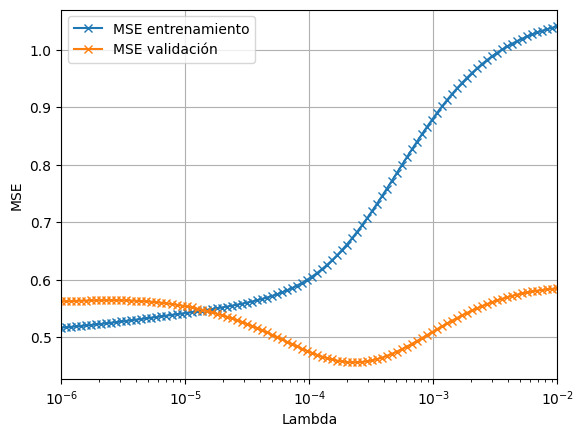

In [30]:
#graficos
plt.plot(lambdas, mse_train_list, label = 'MSE entrenamiento', marker = 'x')
plt.plot(lambdas, mse_valid_list, label = 'MSE validación', marker = 'x')

plt.xscale('log')
plt.xlabel('Lambda')
plt.xlim(1e-6, 1e-2)

plt.ylabel('MSE')

plt.grid(True)
plt.legend()

plt.show()

In [31]:
mejor_lambda_indice = np.argmin(mse_valid_list) #encuentra el índice que minimiza el ECM
mejor_lambda = lambdas[mejor_lambda_indice]
print(f'El lambda que minimiza el MSE de validación es {mejor_lambda}')

El lambda que minimiza el MSE de validación es 0.00022051307399030456


In [32]:
regularizacion.set_params(alpha = mejor_lambda)
pl_regu.fit(X_train, Y_train)

X_test = test[categoricas + numericas]
Y_test = test['Selling_Price']

Y_hat_test = pl_regu.predict(X_test)
mse_test = np.mean((Y_hat_test - Y_test)**2)

print(f'Allí, el MSE de testeo es {mse_test}')

Allí, el MSE de testeo es 0.33936638224137217
